# Modèle pour la prédiction du débit d'entrée pour la station C

## Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb  
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import shap

/Users/nbieszczad/M2DS/Capstone VINCI/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Données 

ATTENTION AU CHANGEMENT D'HEURE ET METTRE LES DONNÉES EN UTC + AJOUTER DONNÉES 2025-2026

In [2]:
# Capteurs
df_sensors = pd.read_csv('/Users/nbieszczad/M2DS/Capstone VINCI/Capstone/Dataset/bronze/sensors_C_20210101_20250101.csv')
df_sensors['ts'] = pd.to_datetime(df_sensors['ts'])

# Débit d'entrée 
df_debit = df_sensors[df_sensors['sensor'] == 'entry_debit'].copy()
df_debit = df_debit.set_index('ts')[['value']].resample('1h').mean() # Le débit est agrégé à l'échelle horaire car les données météo sont à cett échelle.
df_debit.columns = ['debit']

# Météo : dans un premier temps, on va essayer en faisant la moyenne des 14 villes
weather_files = [
    'Aiglemont', 'Chalandry-Elaire', 'Damouzy', 'Dom-le-Mesnil',
    'Flize', 'La-Francheville', 'La-Grandville', 'Les-Ayvelles',
    'Montcy-Notre-Dame', 'Prix-les-Mezieres', 'Saint-Laurent',
    'Ville-sur-Lumes', 'Villers-Semeuse', 'Warcq'
]

weather_frames = []
for city in weather_files:
    try:
        df = pd.read_csv(f'/Users/nbieszczad/M2DS/Capstone VINCI/Capstone/Dataset/bronze/weather_C/{city}_hourly.csv')
        df['date'] = pd.to_datetime(df['date'])
        df = df.set_index('date')[['temperature_2m', 'rain', 'wind_speed_10m']].resample('1h').mean()
        weather_frames.append(df)
    except:
        pass

df_weather = pd.concat(weather_frames).groupby(level=0).mean()
if df_weather.index.tz: df_weather.index = df_weather.index.tz_localize(None)

# Fusion
df = pd.merge(df_debit, df_weather, left_index=True, right_index=True, how='inner')


### Features 

In [4]:
# Pluie décalée (LAG 5h) 
df['rain_lag_5'] = df['rain'].shift(5)

# Features temporelles
df['hour'] = df.index.hour
df['month'] = df.index.month

# Encodage cyclique (pour capturer la continuité 23h → 0h). Sans ca, le modele ne pourra pas faire de lien entre 23h et 00H par exemple. 
# Ca va aussi faire que le modele va potentiellement mettre plus de poids sur 23h que 00h car 23>0
df['sin_hour'] = np.sin(2 * np.pi * df['hour'] / 24)
df['cos_hour'] = np.cos(2 * np.pi * df['hour'] / 24)
df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)
# Essayer de modéliser la courbe de la tendance de la distribution du débit, et d'avoir un parametre à trouver pour le modèle. 

# Lags du débit (inertie hydraulique)
df['debit_lag_1h'] = df['debit'].shift(1)
df['debit_lag_6h'] = df['debit'].shift(6)                     #Faire la prédiction à 3, 12 et 24h
df['debit_lag_24h'] = df['debit'].shift(24)

# Rolling Statistics (fenêtres glissantes) 
df['debit_roll_mean_24h'] = df['debit'].rolling(window=24, min_periods=1).mean()
df['rain_roll_sum_12h'] = df['rain'].rolling(window=12, min_periods=1).sum()
df['debit_roll_mean_6h'] = df['debit'].rolling(window=6, min_periods=1).mean()
df['rain_roll_sum_6h'] = df['rain'].rolling(window=6, min_periods=1).sum()

# Interactions métier (2eme temps): faire de maniere de plus automatique, polynomial features
# Vaut mieux etre sur avant de mettre ce genre de croisements 
df['temp_x_rain'] = df['temperature_2m'] * df['rain_lag_5']  # Pluie chaude vs froide
df['wind_x_rain'] = df['wind_speed_10m'] * df['rain_lag_5']  # Tempêtes

# Features binaires
#df['is_night'] = ((df['hour'] >= 22) | (df['hour'] <= 6)).astype(int)

# Features pour gérer les pics
df['rain_roll_max_3h'] = df['rain'].rolling(window=3, min_periods=1).max()
df['rain_roll_max_6h'] = df['rain'].rolling(window=6, min_periods=1).max()

df['debit_roll_max_6h'] = df['debit'].rolling(window=6, min_periods=1).max()
df['debit_roll_min_6h'] = df['debit'].rolling(window=6, min_periods=1).min()

# Suppression des NaN (dus aux lags)
df_clean = df.dropna()

print(f"Dataset final : {len(df_clean):,} heures")
print(f"Période : {df_clean.index.min()} → {df_clean.index.max()}")
print(f"Features créées : {df_clean.shape[1] - 1} (hors cible)")


Dataset final : 33,368 heures
Période : 2021-01-02 00:00:00 → 2024-12-31 23:00:00
Features créées : 23 (hors cible)


# Prédiction à 3h

## Création des données pour la prédiction à 3h

In [5]:
df_clean['debit_target_3h'] = df_clean['debit'].shift(-3)
df_3h = df_clean.dropna(subset=['debit_target_3h'])

### Split chronologique Train / Validation / Test

In [7]:
feature_cols_3h = [
    'temperature_2m', 'wind_speed_10m', 'rain_lag_5',
    'sin_hour', 'cos_hour', 'sin_month', 'cos_month',
    'debit_lag_6h', 'rain_roll_sum_12h', 'debit_roll_mean_6h',
    'rain_roll_sum_6h', 'rain_roll_max_6h', 'rain_roll_max_3h',
    'debit_roll_max_6h', 'debit_roll_min_6h'
]

X = df_3h[feature_cols_3h]
y = df_3h['debit']

# Split chronologique 60% / 20% / 20%
n = len(X)
n_train = int(n * 0.60)
n_val   = int(n * 0.20)

X_train = X.iloc[:n_train]
y_train = y.iloc[:n_train]

X_val   = X.iloc[n_train:n_train + n_val]
y_val   = y.iloc[n_train:n_train + n_val]

X_test  = X.iloc[n_train + n_val:]
y_test  = y.iloc[n_train + n_val:]

print(f"Train      : {X_train.index.min().date()} → {X_train.index.max().date()}  ({len(X_train):,} obs)")
print(f"Validation : {X_val.index.min().date()} → {X_val.index.max().date()}  ({len(X_val):,} obs)")
print(f"Test       : {X_test.index.min().date()} → {X_test.index.max().date()}  ({len(X_test):,} obs)")

# Train
model = xgb.XGBRegressor(
    max_depth=3, n_estimators=300, learning_rate=0.05,
    reg_alpha=1.0, reg_lambda=5.0,
    random_state=42
)
model.fit(X_train, y_train)

# Validation
y_pred_val   = model.predict(X_val)
y_pred_train = model.predict(X_train)

def print_metrics(label, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{label:12s} → RMSE={rmse:.2f} | MAE={mae:.2f} | R²={r2:.3f}")


print_metrics("Train",      y_train, y_pred_train)
print_metrics("Validation", y_val,   y_pred_val)

gap_r2   = r2_score(y_train, y_pred_train) - r2_score(y_val, y_pred_val)
gap_rmse = np.sqrt(mean_squared_error(y_val, y_pred_val)) - np.sqrt(mean_squared_error(y_train, y_pred_train))
print(f"Gap R²   (train-val) : {gap_r2:.3f}")
print(f"Gap RMSE (val-train) : {gap_rmse:.2f}")


Train      : 2021-01-02 → 2023-06-23  (20,019 obs)
Validation : 2023-06-23 → 2024-03-27  (6,673 obs)
Test       : 2024-03-27 → 2024-12-31  (6,673 obs)
Train        → RMSE=82.23 | MAE=48.49 | R²=0.949
Validation   → RMSE=110.18 | MAE=60.43 | R²=0.941
Gap R²   (train-val) : 0.008
Gap RMSE (val-train) : 27.95
Train        → RMSE=82.23 | MAE=48.49 | R²=0.949
Validation   → RMSE=110.18 | MAE=60.43 | R²=0.941
Gap R²   (train-val) : 0.008
Gap RMSE (val-train) : 27.95


Visualisation du débit prédit vs réel sur la **validation** (le test reste caché jusqu'à la fin).

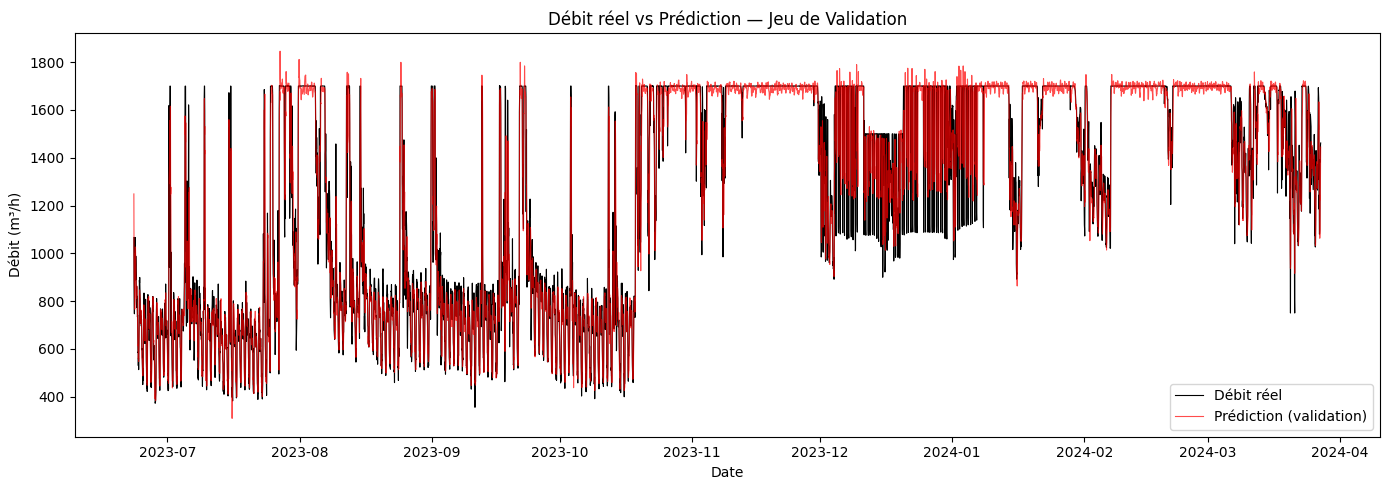

In [8]:
plt.figure(figsize=(14, 5))
plt.plot(y_val.index, y_val, label='Débit réel', color='black', linewidth=0.8)
plt.plot(y_val.index, y_pred_val, label='Prédiction (validation)', color='red', alpha=0.7, linewidth=0.8)
plt.title('Débit réel vs Prédiction — Jeu de Validation')
plt.xlabel('Date')
plt.ylabel('Débit (m³/h)')
plt.legend()
plt.tight_layout()
plt.show()


## Évaluation finale sur le jeu de Test

Train        → RMSE=82.23 | MAE=48.49 | R²=0.949
Validation   → RMSE=110.18 | MAE=60.43 | R²=0.941
TEST         → RMSE=91.59 | MAE=56.80 | R²=0.941


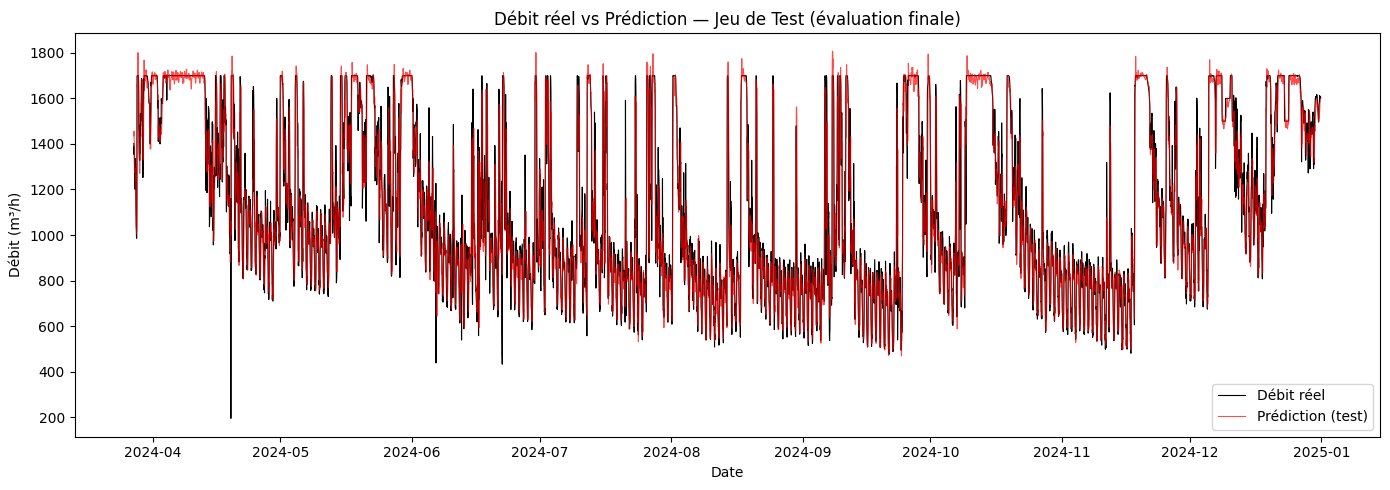

In [9]:
# Évaluation finale sur test
y_pred_test = model.predict(X_test)

print_metrics("Train",      y_train, y_pred_train)
print_metrics("Validation", y_val,   y_pred_val)
print_metrics("TEST",       y_test,  y_pred_test)

# Visualisation
plt.figure(figsize=(14, 5))
plt.plot(y_test.index, y_test, label='Débit réel', color='black', linewidth=0.8)
plt.plot(y_test.index, y_pred_test, label='Prédiction (test)', color='red', alpha=0.7, linewidth=0.8)
plt.title('Débit réel vs Prédiction — Jeu de Test (évaluation finale)')
plt.xlabel('Date')
plt.ylabel('Débit (m³/h)')
plt.legend()
plt.tight_layout()
plt.show()


Il faut ne pas oublier de calculer la standard deviation (demandé par l'organisatrice de capstone).

In [13]:
# ── Métriques finales avec std (bootstrap sur le test) ───────────────────────
def bootstrap_metrics(y_true, y_pred, n_bootstrap=500, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    rmses, maes, r2s = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        rmses.append(np.sqrt(mean_squared_error(y_true.iloc[idx], y_pred[idx])))
        maes.append(mean_absolute_error(y_true.iloc[idx], y_pred[idx]))
        r2s.append(r2_score(y_true.iloc[idx], y_pred[idx]))
    return {
        'RMSE': (np.mean(rmses), np.std(rmses)),
        'MAE':  (np.mean(maes),  np.std(maes)),
        'R²':   (np.mean(r2s),   np.std(r2s))
    }

print(f"\n── Métriques finales avec intervalle de confiance (bootstrap 500) ──")
for label, y_true, y_pred in [
    ("Train",      y_train,  y_pred_train),
    ("Validation", y_val,    y_pred_val),
    ("Test",       y_test,   y_pred_test),
]:
    stats = bootstrap_metrics(y_true, y_pred)
    print(f"{label:12s} → "
          f"RMSE={stats['RMSE'][0]:.2f} ± {stats['RMSE'][1]:.2f} | "
          f"MAE={stats['MAE'][0]:.2f} ± {stats['MAE'][1]:.2f} | "
          f"R²={stats['R²'][0]:.3f} ± {stats['R²'][1]:.3f}")


── Métriques finales avec intervalle de confiance (bootstrap 500) ──
Train        → RMSE=82.19 ± 1.17 | MAE=48.49 ± 0.47 | R²=0.949 ± 0.001
Train        → RMSE=82.19 ± 1.17 | MAE=48.49 ± 0.47 | R²=0.949 ± 0.001
Validation   → RMSE=110.32 ± 2.12 | MAE=60.48 ± 1.09 | R²=0.941 ± 0.002
Validation   → RMSE=110.32 ± 2.12 | MAE=60.48 ± 1.09 | R²=0.941 ± 0.002
Test         → RMSE=91.55 ± 1.91 | MAE=56.80 ± 0.87 | R²=0.941 ± 0.003
Test         → RMSE=91.55 ± 1.91 | MAE=56.80 ± 0.87 | R²=0.941 ± 0.003


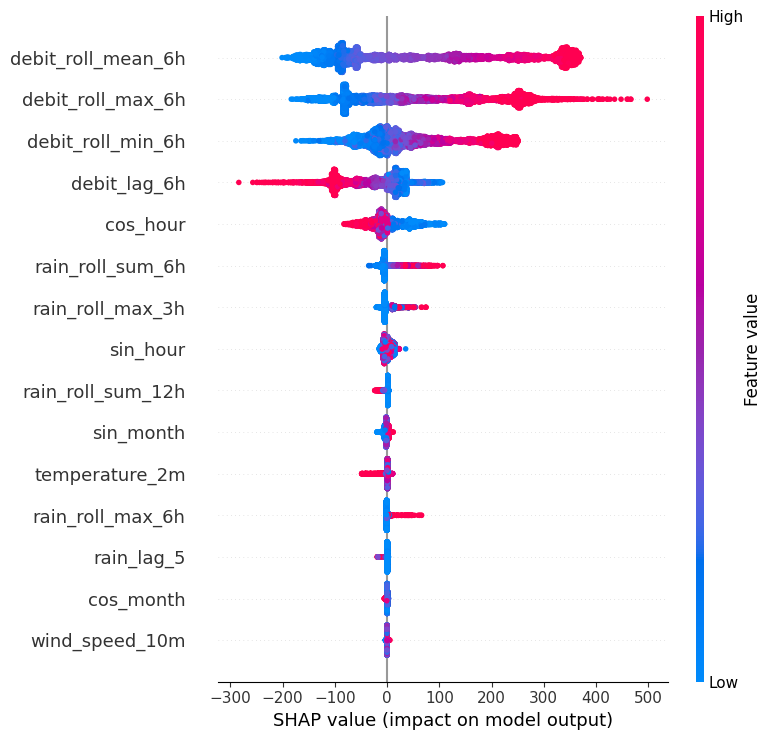

In [10]:
# Après avoir entraîné le modèle final
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Résumé global
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.show()

# Impact de chaque feature sur une prédiction individuelle
shap.force_plot(explainer.expected_value, shap_values[0], X_test.iloc[0])

Regardons les métriques sans la plage 1500-1700 m3/h

In [14]:
# Métriques SANS les points proches du hard cap
mask_no_cap = y_test < 1500

y_test_filtered = y_test[mask_no_cap]
y_pred_filtered = y_pred_test[mask_no_cap]

print(f"Points hors cap: {mask_no_cap.sum()} / {len(y_test)}")
print(f"RMSE (hors cap): {np.sqrt(mean_squared_error(y_test_filtered, y_pred_filtered)):.2f}")
print(f"MAE  (hors cap): {mean_absolute_error(y_test_filtered, y_pred_filtered):.2f}")
print(f"R²   (hors cap): {r2_score(y_test_filtered, y_pred_filtered):.3f}")

# Métriques AVEC les points proches du hard cap
mask_cap = y_test >= 1500
y_test_cap = y_test[mask_cap]
y_pred_cap = y_pred_test[mask_cap]

print(f"\nPoints au cap: {mask_cap.sum()} / {len(y_test)}")
print(f"RMSE (au cap): {np.sqrt(mean_squared_error(y_test_cap, y_pred_cap)):.2f}")
print(f"MAE  (au cap): {mean_absolute_error(y_test_cap, y_pred_cap):.2f}")
print(f"R²   (au cap): {r2_score(y_test_cap, y_pred_cap):.3f}")

Points hors cap: 4901 / 6673
RMSE (hors cap): 92.29
MAE  (hors cap): 59.46
R²   (hors cap): 0.842

Points au cap: 1772 / 6673
RMSE (au cap): 89.63
MAE  (au cap): 49.42
R²   (au cap): -1.270


## Prédiction à 12h